In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score


In [3]:
dataset = pd.read_csv("Iris_6.csv")
dataset.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
X = dataset.iloc[:, 1:5].values   # Sepal & Petal columns ONLY
y = dataset.iloc[:, 5].values     # Species


In [7]:
print("X shape:", X.shape)
print("y sample:", y[:5])
print("Unique classes:", set(y))


X shape: (150, 4)
y sample: ['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']
Unique classes: {'Iris-versicolor', 'Iris-setosa', 'Iris-virginica'}


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)


In [11]:
from sklearn.naive_bayes import GaussianNB

classifier = GaussianNB()
classifier.fit(X_train, y_train)


GaussianNB()

In [13]:
y_pred = classifier.predict(X_test)


In [15]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm


array([[13,  0,  0],
       [ 0, 16,  0],
       [ 0,  0,  9]])

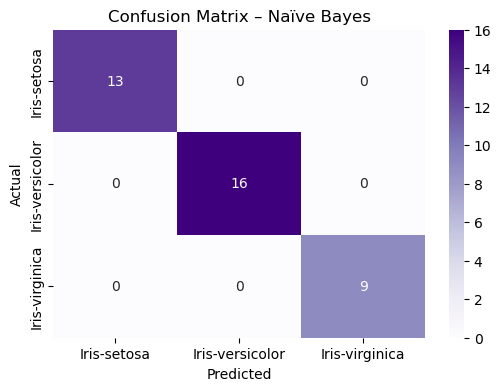

In [32]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Naïve Bayes")
plt.show()


In [19]:
accuracy = accuracy_score(y_test, y_pred)
accuracy


1.0

In [21]:
error_rate = 1 - accuracy
error_rate


0.0

In [23]:
precision = precision_score(y_test, y_pred, average='macro')
precision


1.0

In [25]:
recall = recall_score(y_test, y_pred, average='macro')
recall


1.0

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       1.00      1.00      1.00        16
 Iris-virginica       1.00      1.00      1.00         9

       accuracy                           1.00        38
      macro avg       1.00      1.00      1.00        38
   weighted avg       1.00      1.00      1.00        38

